In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [31]:
df = pd.read_parquet('../data/processed/daily_features.parquet')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

print('Data shape:', df.shape)
print('Date range:', df['date'].min(), 'to', df['date'].max())
df[['date', 'count']].head()

Data shape: (2192, 16)
Date range: 2019-01-01 00:00:00 to 2024-12-31 00:00:00


,date,count
0,2019-01-01,381
1,2019-01-02,689
2,2019-01-03,636
3,2019-01-04,763
4,2019-01-05,341


In [32]:
test_days = 90
train = df.iloc[:-test_days].copy()
test = df.iloc[-test_days:].copy()

print('Training set:', len(train), 'days', train['date'].min(), 'to', train['date'].max())
print('Test set:', len(test), 'days', test['date'].min(), 'to', test['date'].max())

Training set: 2102 days 2019-01-01 00:00:00 to 2024-10-02 00:00:00
Test set: 90 days 2024-10-03 00:00:00 to 2024-12-31 00:00:00


In [ ]:
y_true = test['count'].values.astype(float)

y_train = train['count'].astype(float).values

# AR(1) rolling one-step with expanding re-fit
history = y_train.tolist()
ar1_pred = []
phi_values = []

for actual in y_true:
    hist = np.array(history, dtype=float)
    x_ar = hist[:-1]
    y_ar = hist[1:]

    phi, c = np.polyfit(x_ar, y_ar, 1)
    y_hat = c + phi * hist[-1]
    y_hat = max(0.0, y_hat)

    ar1_pred.append(y_hat)
    phi_values.append(phi)

    # update with observed value for next 1-step forecast
    history.append(float(actual))

ar1_pred = np.array(ar1_pred, dtype=float)

print('AR(1) avg phi:', round(float(np.mean(phi_values)), 4))

In [ ]:
def mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.where(y_true == 0, 1, y_true)
    return np.mean(np.abs((y_true - y_pred) / denom)) * 100

results = pd.DataFrame([
    {
        'model': 'AR(1) - rolling 1-step',
        'MAE': mean_absolute_error(y_true, ar1_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, ar1_pred)),
        'MAPE': mape(y_true, ar1_pred),
        'R2': r2_score(y_true, ar1_pred),
    },
])

results

,model,MAE,RMSE,MAPE,R2
0,MA(1),138.435661,178.277476,28.897275,-0.091281


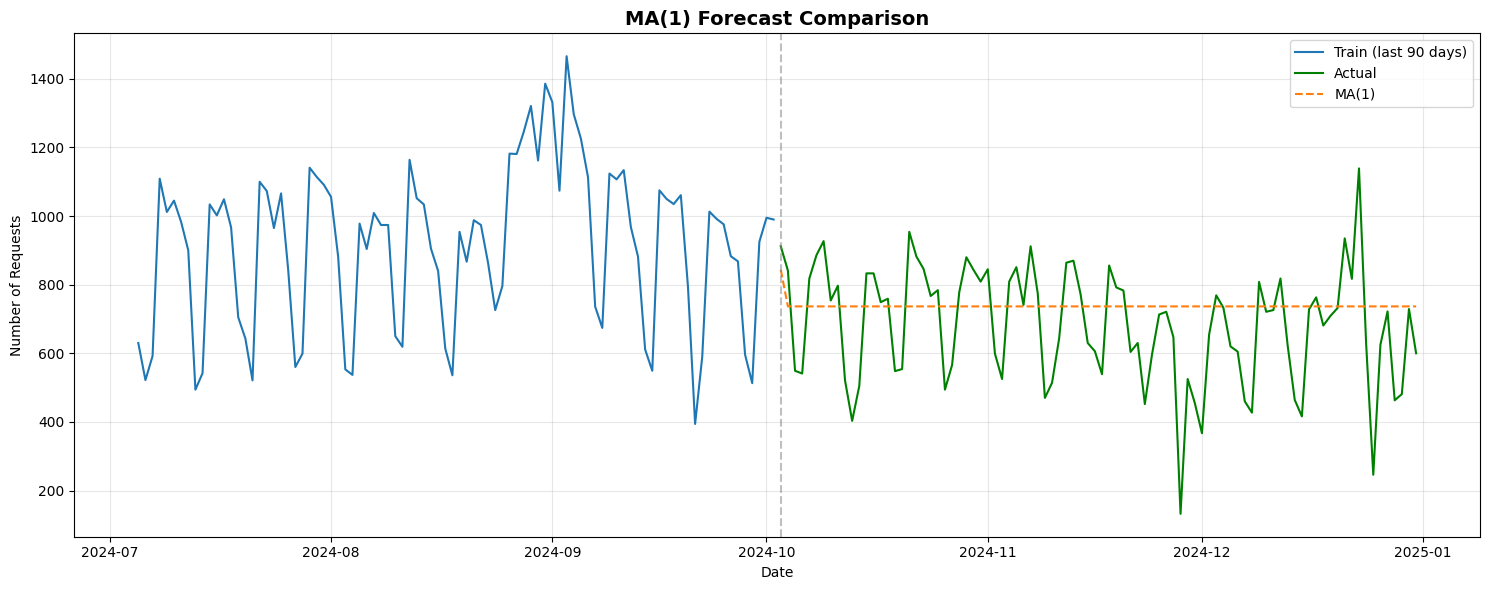

In [ ]:
plot_train = train.tail(90)

plt.figure(figsize=(15, 6))
plt.plot(plot_train['date'], plot_train['count'], label='Train (last 90 days)', linewidth=1.5)
plt.plot(test['date'], y_true, label='Actual', linewidth=1.5, color='green')
plt.plot(test['date'], ar1_pred, label='AR(1) - rolling 1-step', linestyle='--', linewidth=1.5)
plt.axvline(x=test['date'].min(), color='gray', linestyle='--', alpha=0.5)
plt.title('AR(1) Rolling One-Step Forecast Comparison', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Number of Requests')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()